Nick and David

In [ ]:

#https://www.kaggle.com/datasets/ritwikb3/heart-disease-statlog

In [ ]:
#Downloading all necessary libraries and datasets for this algorithm
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
#Importing the heart disease dataset into the google colab notebook
#displaying the table to make sure the dataset was imported correctly
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("Heart_disease_statlog.csv")
df

Saving Heart_disease_statlog.csv to Heart_disease_statlog.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,2,172,199,1,0,162,0,0.5,0,0,3,0
266,44,1,1,120,263,0,0,173,0,0.0,0,0,3,0
267,56,0,1,140,294,0,2,153,0,1.3,1,0,1,0
268,57,1,3,140,192,0,0,148,0,0.4,1,0,2,0


In [ ]:
df.isnull().sum() # Making sure there is no null values in the datasets

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.columns # displaying all columns as refrence for future code

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
print("=" * 60)
print("Heart Disease Stats")
print("=" * 60)

Heart Disease Stats


In [ ]:
#setting a variable towards all features
x=df[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']]
#setting a variable towards the target variable which is named target
y=df['target']

In [ ]:
#This will split the data into traing and testing sets
#30% into testing and the rest of the 70% into training
x_train, x_test, y_train, y_test =train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
#we scaled all features so that all different numbers will scale equally when running the algorithm
#converting all numbers into the same unit or meaurement
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
print("\n" + "=" * 60)
print("Testing Different SVM Kernels")
print("=" * 60)


Testing Different SVM Kernels


In [ ]:
#We are testing the data using a polynomial kernel
#Showing how accurate the data is using the polynomial kernel
#we must use a s shaped curve in order it to be polynomial
print("\n3. Polynomial Kernel (degree=3):")
print("  -Uses polynomial curves (like parabolas) to seperate classes")
print("  -degree=3 means it can make S-shaped curves")
svm_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale')
svm_poly.fit(x_train_scaled, y_train)
y_pred_poly = svm_poly.predict(x_test_scaled)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"  -Accuracy: {accuracy_poly * 100:.2f}%")


3. Polynomial Kernel (degree=3):
  -Uses polynomial curves (like parabolas) to seperate classes
  -degree=3 means it can make S-shaped curves
  -Accuracy: 80.25%


In [ ]:
#importing more libraries to test the precision, recall, and f1 accuracy
from sklearn import metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_poly))

precision = metrics.precision_score(y_test, y_pred_poly)
recall = metrics.recall_score(y_test, y_pred_poly)
f1 = metrics.f1_score(y_test, y_pred_poly)

print(f"The precision of the model is {precision:.2f}.")
print(f"The recall of the model is {recall:.2f}.")
print(f"The F1-score of the model is {f1:.2f}.")

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        49
           1       0.79      0.69      0.73        32

    accuracy                           0.80        81
   macro avg       0.80      0.78      0.79        81
weighted avg       0.80      0.80      0.80        81

The precision of the model is 0.79.
The recall of the model is 0.69.
The F1-score of the model is 0.73.


In [ ]:
print("\n" + "=" * 60)
print(f"Detailed Classification Report ({best_kernel} Kernel)")
print("=" * 60)


Detailed Classification Report (Polynomial Kernel)


In [ ]:
#double checking the shape of the dataset and variables
print(x.shape)
print(y.shape)

(270, 13)
(270,)


In [ ]:
#We will only use two features for now so we must make new variables with only two features
#the testing and training size is the same
x_2d=x[['age', 'sex']]
x_train_2d, x_test_2d, y_train_2d, y_test_2d = train_test_split(
    x_2d, y, test_size=0.3, random_state=42
)

<function matplotlib.pyplot.show(close=None, block=None)>

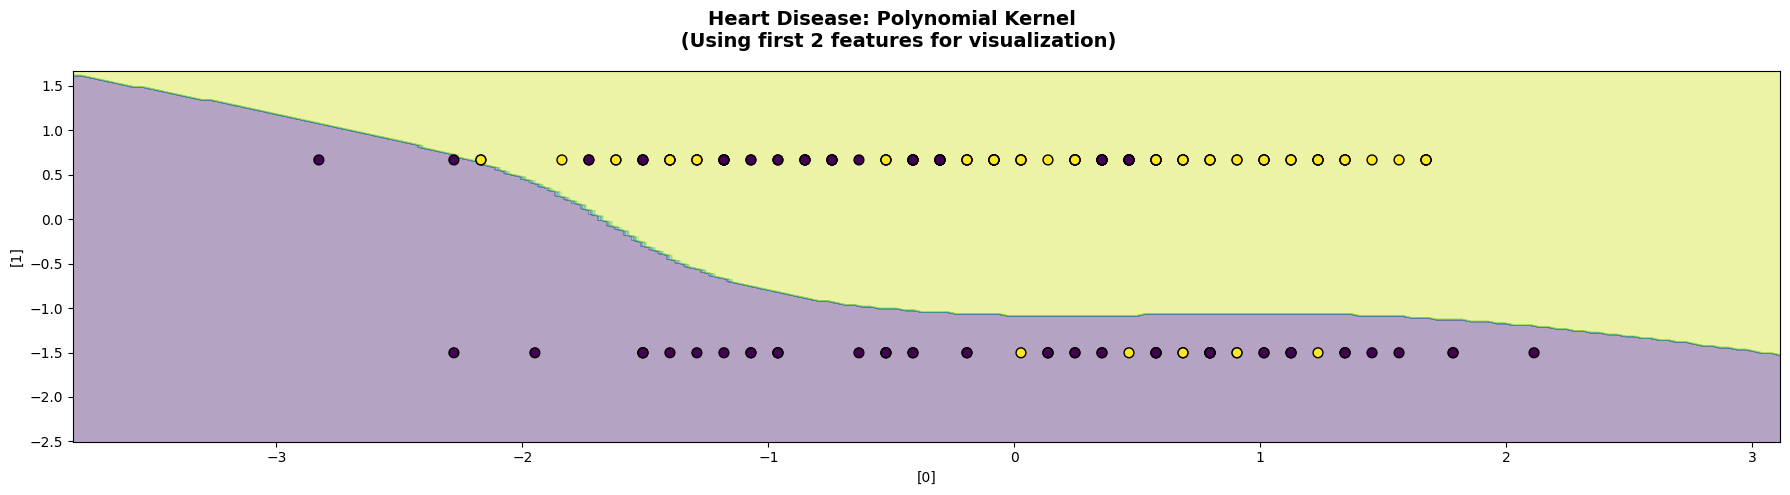

In [ ]:
#Scaling the data as we done before
scaler_2d = StandardScaler()
x_train_2d_scaled = scaler_2d.fit_transform(x_train_2d)
x_test_2d_scaled = scaler_2d.transform(x_test_2d)

#This will create the figure with one subplot applying to the polynomial kernel
fig, axes = plt.subplots(figsize=(18, 5))

kernels = [
    ('poly', 'Polynomial', accuracy_poly)
]
#This will creat the 2d grid with the testing and trained data
#Making the boundries of our data
x_min = x_train_2d_scaled[:, 0].min() - 1
x_max = x_train_2d_scaled[:, 0].max() + 1
y_min = x_train_2d_scaled[:, 1].min() - 1
y_max = x_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
#Plotting the kernel with the scaled features
model=SVC(kernel='poly', degree=3, C=1.0, gamma='scale')
model.fit(x_train_2d_scaled, y_train_2d)
#Showing the actual boundaries
z = model.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)
#This will just give you background color of the grid
axes.contourf(xx, yy, z, alpha=0.4, cmap='viridis')
#plotting the actual traing points
axes.scatter(x_train_2d_scaled[:, 0], x_train_2d_scaled[:, 1],
                      c=y_train_2d, edgecolors='k', cmap='viridis', s=50)
# adding all labels and title for the plot
#Showing the final results
axes.set_xlabel([0], fontsize=10)
axes.set_ylabel([1], fontsize=10)
plt.suptitle('Heart Disease: Polynomial Kernel \n (Using first 2 features for visualization)',
               fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show

We decided to use dataset that used stats from patients. We wanted to use these stats to determine there risk of a heart disease. We trained and tested the data before using the algorithm and we a got a 80% accuracy that it will fit the algorothm. The algorithm will seperate the two classes we have identified which is whether they have a heary disease or not. The line you see is what seperates both classes. Each point is the support which will tell you what class they are in depending on the margin. Depending on the position of the points and how far the points are from the line, it will tell you or give you an idea of the risk of heart disease. We want the biggest margin between the classes to maximize the confidence of our decision. We wanted to only use a 2d plot so we only used the first features which is the age and the sex of the patients we gathered from the data. As you can see some of the yellow points have crossed over the line which means they have a way higher chance of getting a heart disease. Its also good to note we trained and tested the rest of the data but we are using the age and sex for the plot. They are lined up because its either male or female.